# Exploratory Data Analysis — ULB Credit Card 2013 Dataset

**Dataset:** ULB Credit Card Fraud Detection 2013 (Université Libre de Bruxelles)

**Purpose:** Validate data quality, understand feature distributions (PCA-anonymised V1–V28 + Time + Amount), assess feature relevance for fraud detection, and decide which columns to keep/remove before model training.

**Sections:**
1. Setup & Loading
2. Missing Values
3. Class Distribution
4. Descriptive Statistics
5. Feature Distributions
6. Correlation Analysis
7. Feature–Target Association
8. Mutual Information
9. Outlier Analysis
10. `Time` and `Amount` Analysis
11. Conclusions & Decisions

## 1. Setup & Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = Path("..") / "datasets"
df = pd.read_csv(DATA_DIR / "creditcard_2013.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names ({len(df.columns)}):\n{list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
df.head()

Shape: 284,807 rows × 31 columns

Column names (31):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [2]:
# Separate feature types
TARGET = "Class"
PCA_FEATURES = [f"V{i}" for i in range(1, 29)]  # V1–V28
INTERPRETABLE = ["Time", "Amount"]
ALL_FEATURES = PCA_FEATURES + INTERPRETABLE

print(f"Target: {TARGET}")
print(f"PCA features ({len(PCA_FEATURES)}): V1 … V28")
print(f"Interpretable features ({len(INTERPRETABLE)}): {INTERPRETABLE}")
print(f"Total features: {len(ALL_FEATURES)}")

Target: Class
PCA features (28): V1 … V28
Interpretable features (2): ['Time', 'Amount']
Total features: 30


## 2. Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

if missing_df.empty:
    print("✓ No missing values in any column.")
else:
    print(f"⚠ {len(missing_df)} columns with missing values:")
    display(missing_df)

print(f"\nTotal cells: {df.shape[0] * df.shape[1]:,}")
print(f"Total missing: {df.isnull().sum().sum():,}")

✓ No missing values in any column.

Total cells: 8,829,017
Total missing: 0


## 3. Class Distribution

Class distribution:
  0 (Legit):    284,315  (99.827%)
  1 (Fraud):        492  (0.173%)

Imbalance ratio (legit:fraud): 577.9:1


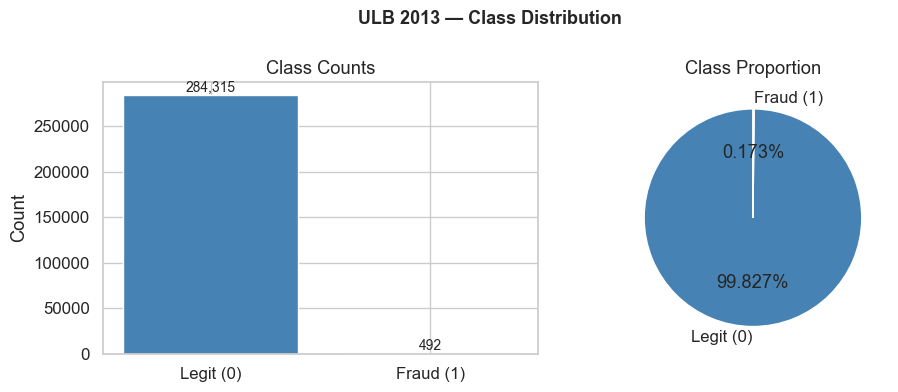

In [4]:
class_counts = df[TARGET].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(3)

print("Class distribution:")
for label, count in class_counts.items():
    print(f"  {label} ({'Fraud' if label == 1 else 'Legit'}): {count:>10,}  ({class_pct[label]:.3f}%)")
print(f"\nImbalance ratio (legit:fraud): {class_counts[0] / class_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(["Legit (0)", "Fraud (1)"], class_counts.values,
                   color=["steelblue", "crimson"])
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{count:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(class_counts.values, labels=["Legit (0)", "Fraud (1)"],
            autopct="%1.3f%%", colors=["steelblue", "crimson"], startangle=90)
axes[1].set_title("Class Proportion")

plt.suptitle("ULB 2013 — Class Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Descriptive Statistics

In [5]:
print("=" * 60)
print("ALL FEATURES — Descriptive Statistics")
print("=" * 60)
df[ALL_FEATURES].describe().T.round(4)

ALL FEATURES — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950
V10,284807.0000,0.0000,1.0888,-24.5883,-0.5354,-0.0929,0.4539,23.7451


In [6]:
# Note on PCA features: V1–V28 are principal components from PCA,
# so they should be centered near 0 with unit-ish variance.
# Let's verify this.
pca_stats = df[PCA_FEATURES].agg(["mean", "std"]).T
pca_stats.columns = ["Mean", "Std"]
print("PCA features — Mean and Std summary:")
print(f"  Mean range: [{pca_stats['Mean'].min():.4f}, {pca_stats['Mean'].max():.4f}]")
print(f"  Std  range: [{pca_stats['Std'].min():.4f}, {pca_stats['Std'].max():.4f}]")
print(f"\nNote: PCA features are NOT standardised (means ≠ 0, stds vary).")
print("This is expected — the PCA was applied before public release,")
print("but the resulting components were not re-scaled.")
display(pca_stats)

PCA features — Mean and Std summary:
  Mean range: [-0.0000, 0.0000]
  Std  range: [0.3301, 1.9587]

Note: PCA features are NOT standardised (means ≠ 0, stds vary).
This is expected — the PCA was applied before public release,
but the resulting components were not re-scaled.


,Mean,Std
V1,0.0000,1.9587
V2,0.0000,1.6513
V3,-0.0000,1.5163
V4,0.0000,1.4159
V5,0.0000,1.3802
V6,0.0000,1.3323
V7,-0.0000,1.2371
V8,0.0000,1.1944
V9,-0.0000,1.0986
V10,0.0000,1.0888


## 5. Feature Distributions

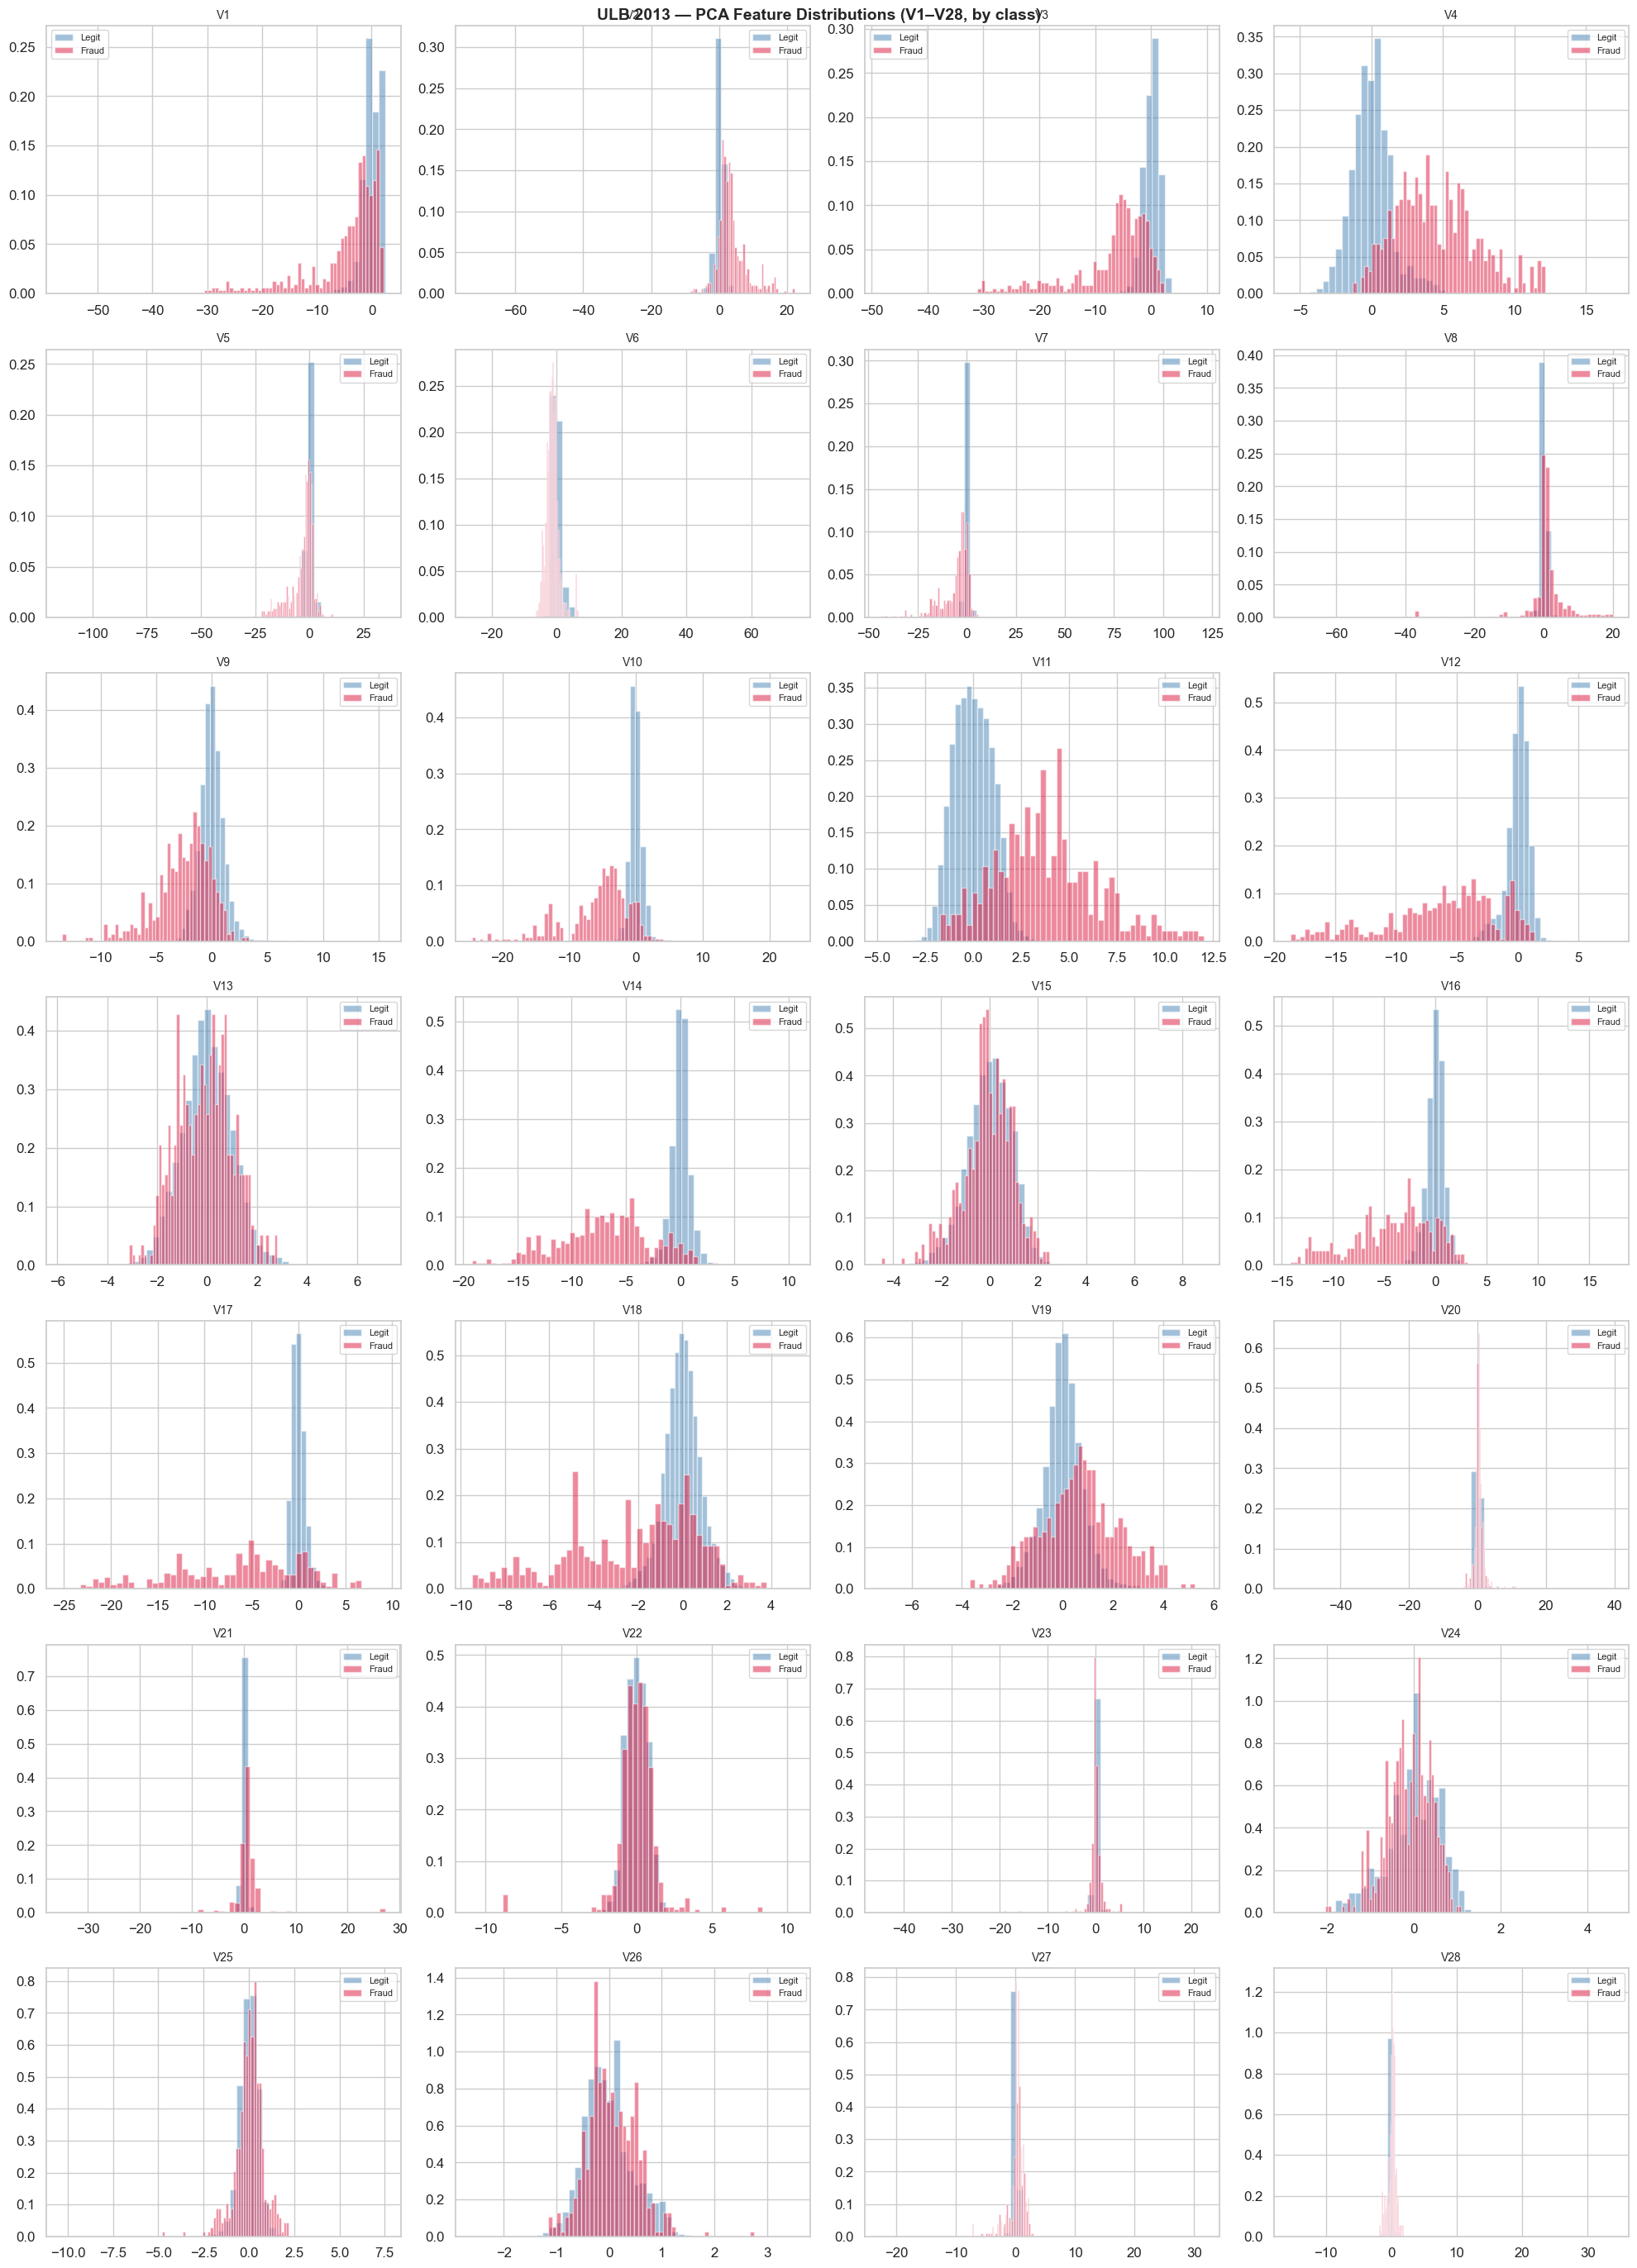

In [7]:
# PCA feature distributions — split by class
n_cols = 4
n_rows = int(np.ceil(len(PCA_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(PCA_FEATURES):
    ax = axes[i]
    for label, color, name in [(0, "steelblue", "Legit"), (1, "crimson", "Fraud")]:
        subset = df.loc[df[TARGET] == label, col]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(len(PCA_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ULB 2013 — PCA Feature Distributions (V1–V28, by class)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

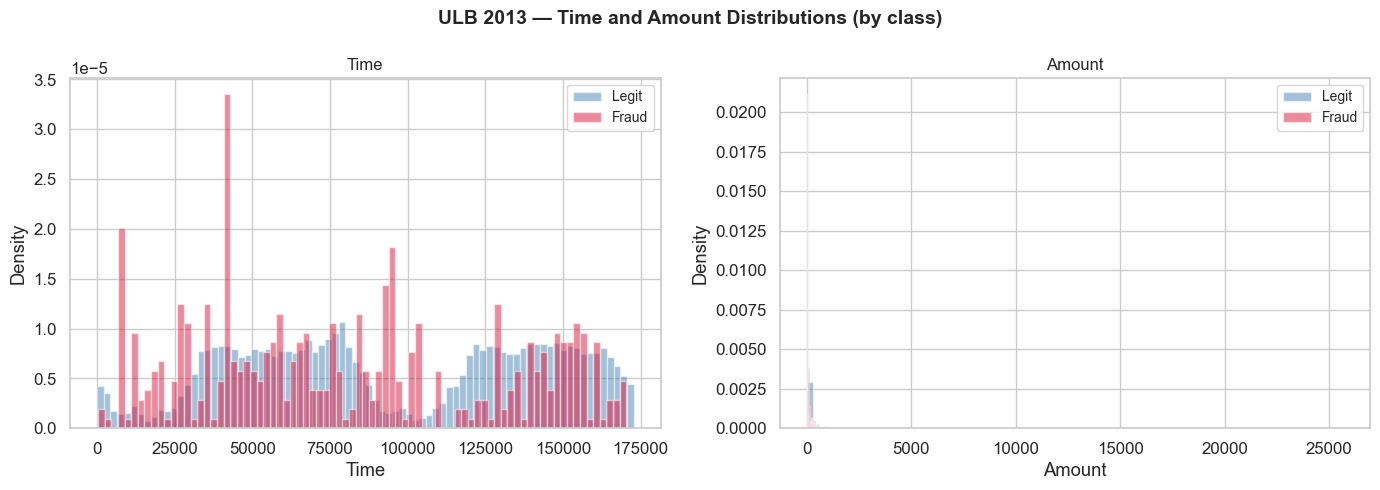

In [8]:
# Time and Amount distributions — split by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(INTERPRETABLE):
    ax = axes[i]
    for label, color, name in [(0, "steelblue", "Legit"), (1, "crimson", "Fraud")]:
        subset = df.loc[df[TARGET] == label, col]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.suptitle("ULB 2013 — Time and Amount Distributions (by class)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

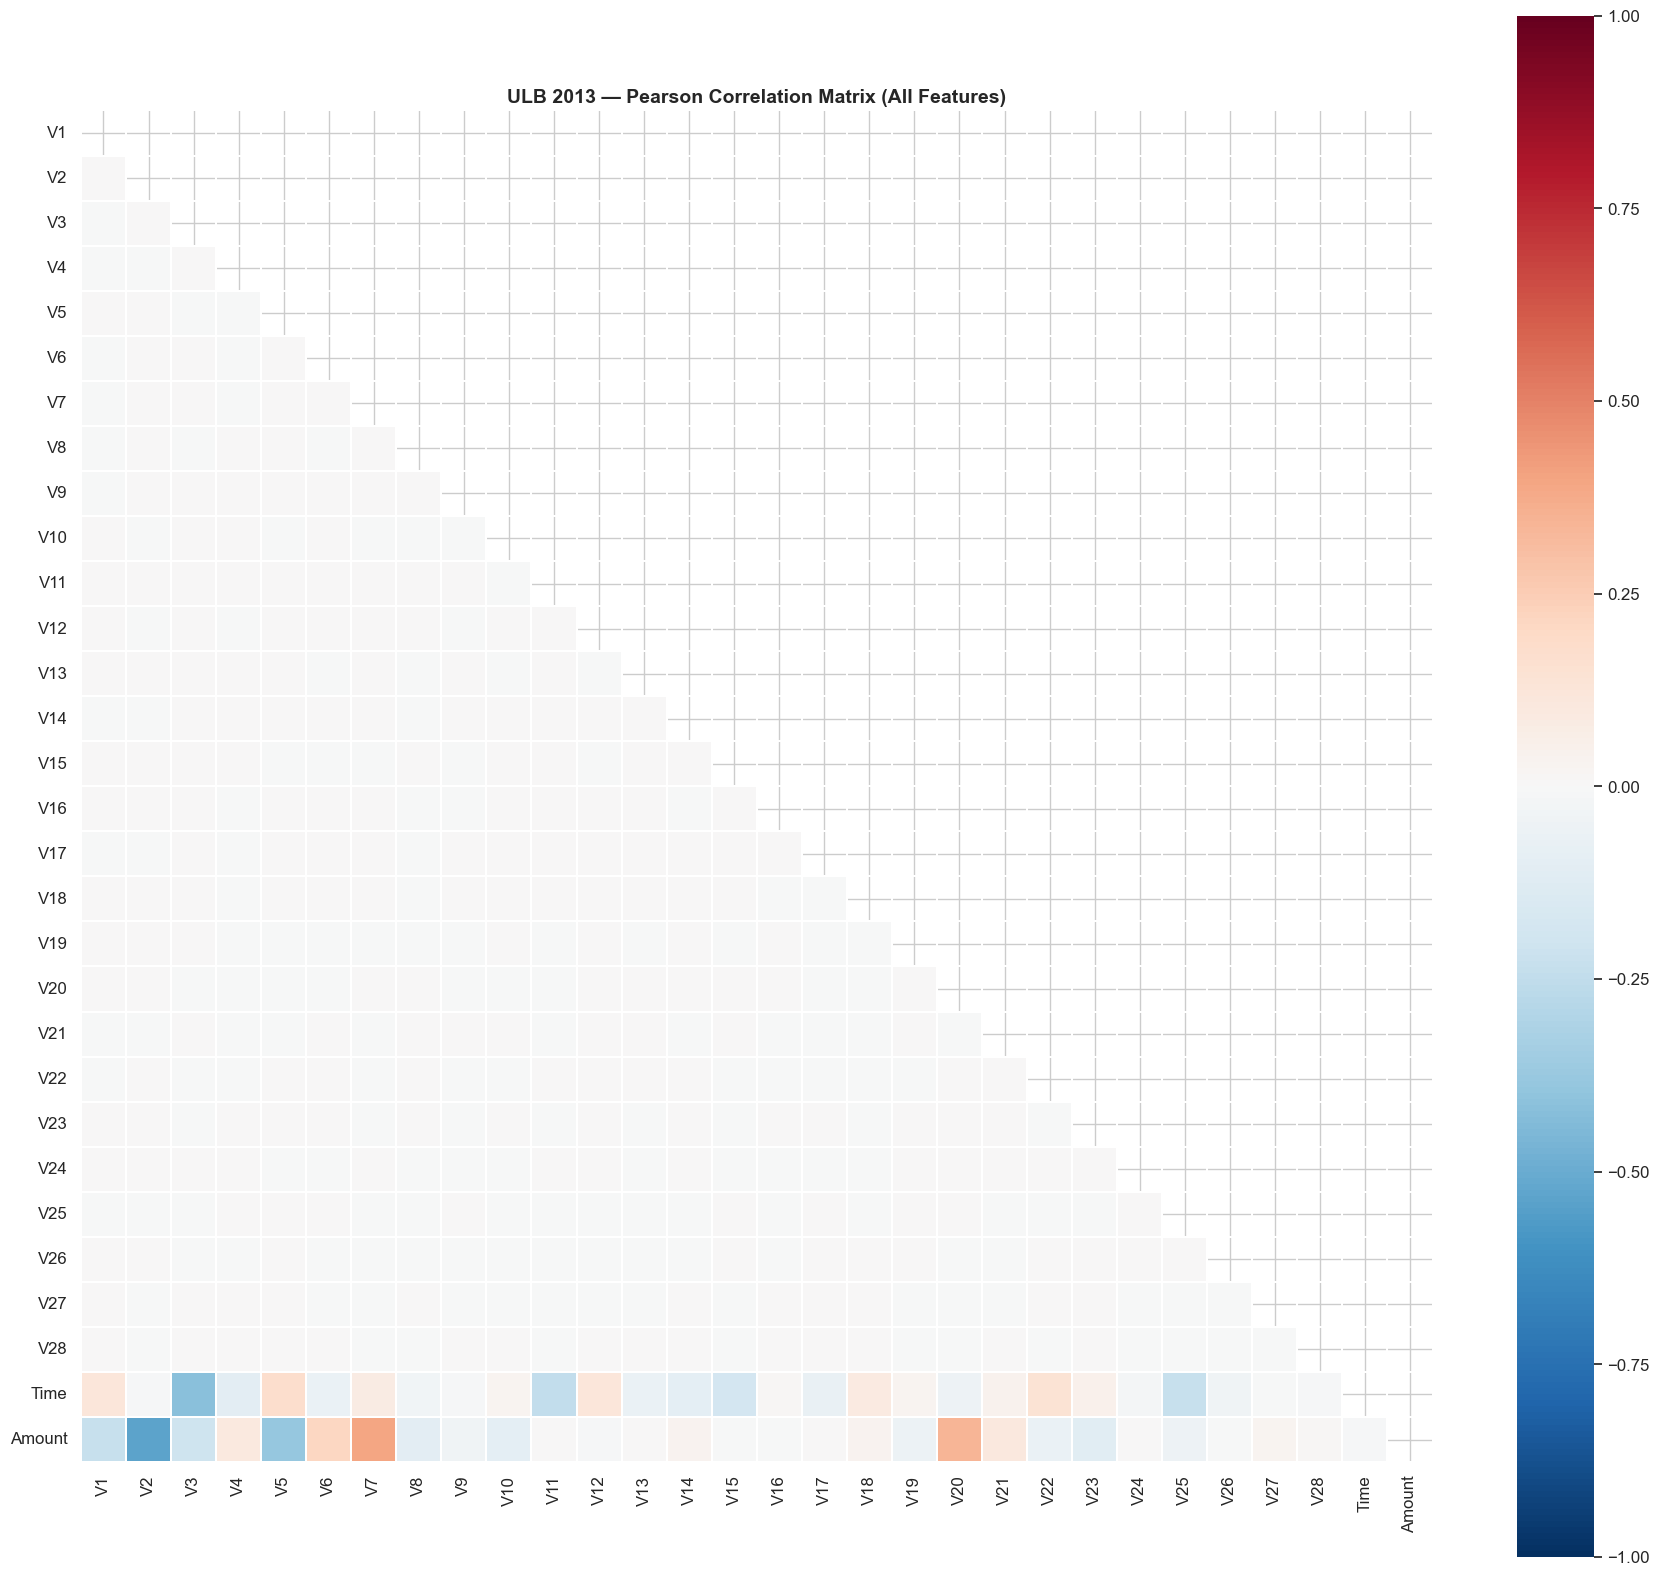

Note: PCA features (V1–V28) are principal components and should
be approximately uncorrelated by construction.


In [9]:
# Pearson correlation matrix for all features
corr = df[ALL_FEATURES].corr()

plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3)
plt.title("ULB 2013 — Pearson Correlation Matrix (All Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Note: PCA features (V1–V28) are principal components and should")
print("be approximately uncorrelated by construction.")

In [10]:
# Identify highly correlated pairs (|r| > 0.7)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append({
                "Feature 1": corr.columns[i],
                "Feature 2": corr.columns[j],
                "Pearson r": round(r, 4)
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values("Pearson r", key=abs, ascending=False)
    print(f"⚠ {len(hc_df)} feature pairs with |r| > 0.70:")
    display(hc_df.reset_index(drop=True))
else:
    print("✓ No feature pairs with |r| > 0.70.")
    print("  This is expected: PCA features are orthogonal by construction,")
    print("  and Time/Amount were not part of the PCA.")

# Also show top-10 absolute correlations for reference
print("\nTop-10 absolute correlations (for reference):")
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        corr_pairs.append({
            "Feature 1": corr.columns[i],
            "Feature 2": corr.columns[j],
            "|r|": round(abs(corr.iloc[i, j]), 4)
        })
top10_corr = pd.DataFrame(corr_pairs).nlargest(10, "|r|")
display(top10_corr.reset_index(drop=True))

✓ No feature pairs with |r| > 0.70.
  This is expected: PCA features are orthogonal by construction,
  and Time/Amount were not part of the PCA.

Top-10 absolute correlations (for reference):


,Feature 1,Feature 2,|r|
0,V2,Amount,0.5314
1,V3,Time,0.4196
2,V7,Amount,0.3973
3,V5,Amount,0.3864
4,V20,Amount,0.3394
5,V11,Time,0.2477
6,V25,Time,0.2331
7,V1,Amount,0.2277
8,V6,Amount,0.2160
9,V3,Amount,0.2109


## 7. Feature–Target Association

,Feature,Point-Biserial r,p-value,Significant (p<0.001)
0,V17,-0.3265,0.0000,True
1,V14,-0.3025,0.0000,True
2,V12,-0.2606,0.0000,True
3,V10,-0.2169,0.0000,True
4,V16,-0.1965,0.0000,True
5,V3,-0.1930,0.0000,True
6,V7,-0.1873,0.0000,True
7,V11,0.1549,0.0000,True
8,V4,0.1334,0.0000,True
9,V18,-0.1115,0.0000,True


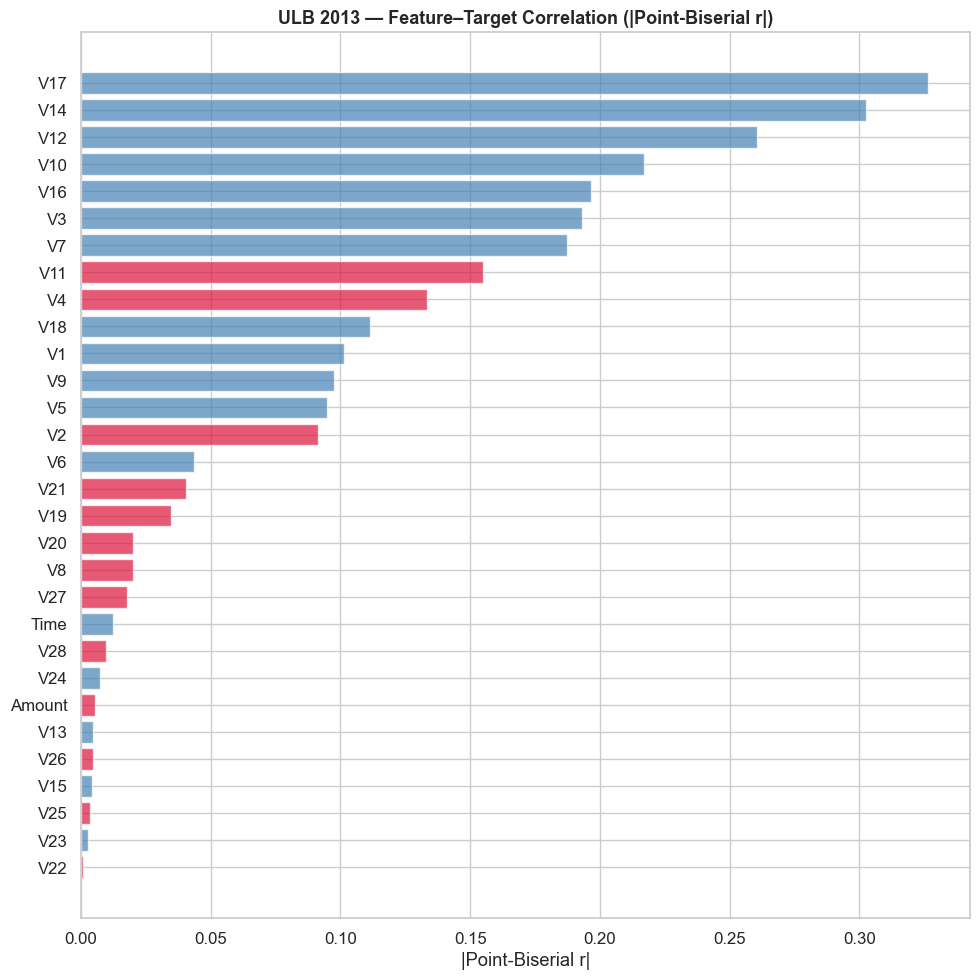

In [11]:
# Point-biserial correlation: each feature vs binary target
from scipy.stats import pointbiserialr

pb_results = []
for col in ALL_FEATURES:
    r, p = pointbiserialr(df[TARGET], df[col])
    pb_results.append({"Feature": col, "Point-Biserial r": round(r, 4), "p-value": p})

pb_df = pd.DataFrame(pb_results).sort_values("Point-Biserial r", key=abs, ascending=False)
pb_df["Significant (p<0.001)"] = pb_df["p-value"] < 0.001
display(pb_df.reset_index(drop=True))

# Horizontal bar chart
plt.figure(figsize=(10, 10))
colors = ["crimson" if r > 0 else "steelblue" for r in pb_df["Point-Biserial r"]]
plt.barh(pb_df["Feature"], pb_df["Point-Biserial r"].abs(), color=colors, alpha=0.7)
plt.xlabel("|Point-Biserial r|")
plt.title("ULB 2013 — Feature–Target Correlation (|Point-Biserial r|)", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

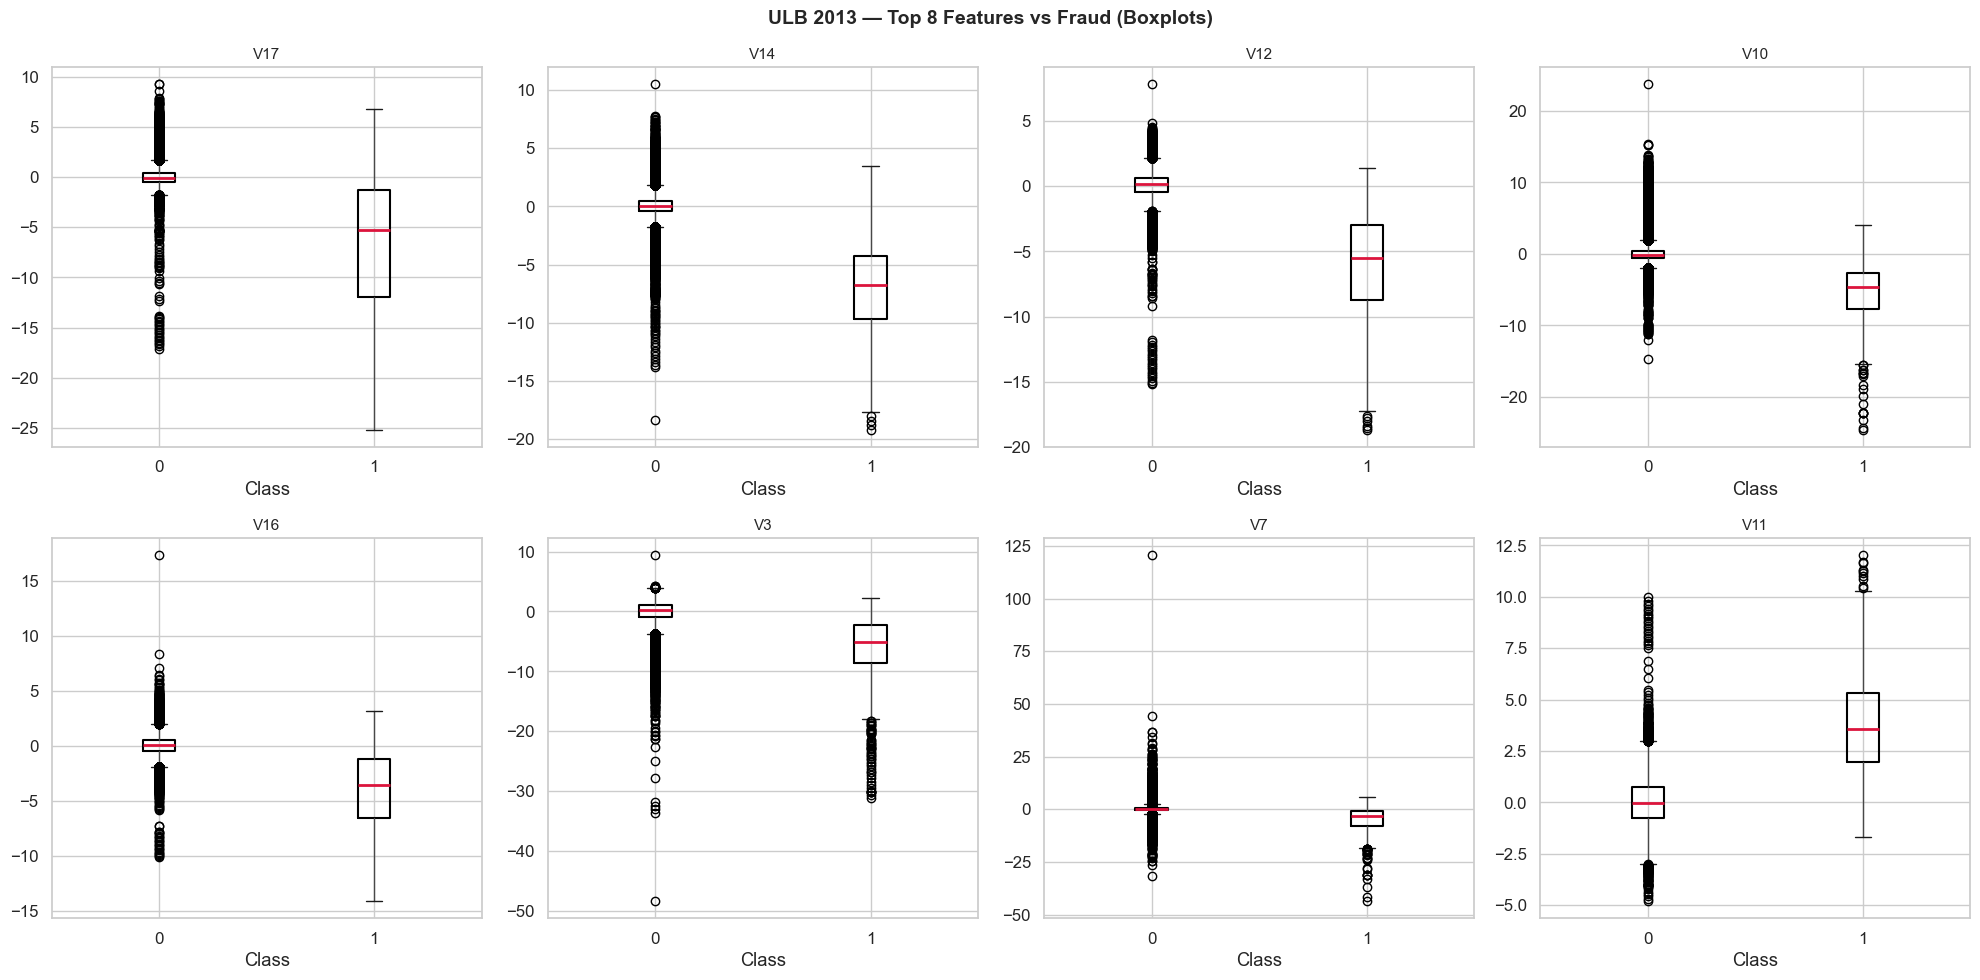

In [12]:
# Boxplots: top 8 most correlated features vs target
top8 = pb_df.head(8)["Feature"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(top8):
    ax = axes[i]
    df.boxplot(column=col, by=TARGET, ax=ax,
              boxprops=dict(linewidth=1.5),
              medianprops=dict(color="crimson", linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Class")
    ax.set_ylabel("")

plt.suptitle("ULB 2013 — Top 8 Features vs Fraud (Boxplots)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Mutual Information

,Feature,MI Score,Type
0,V17,0.0082,PCA
1,V14,0.0081,PCA
2,V12,0.0076,PCA
3,V10,0.0075,PCA
4,V11,0.0068,PCA
5,V16,0.0062,PCA
6,V4,0.0049,PCA
7,V3,0.0048,PCA
8,V9,0.0043,PCA
9,V18,0.0043,PCA


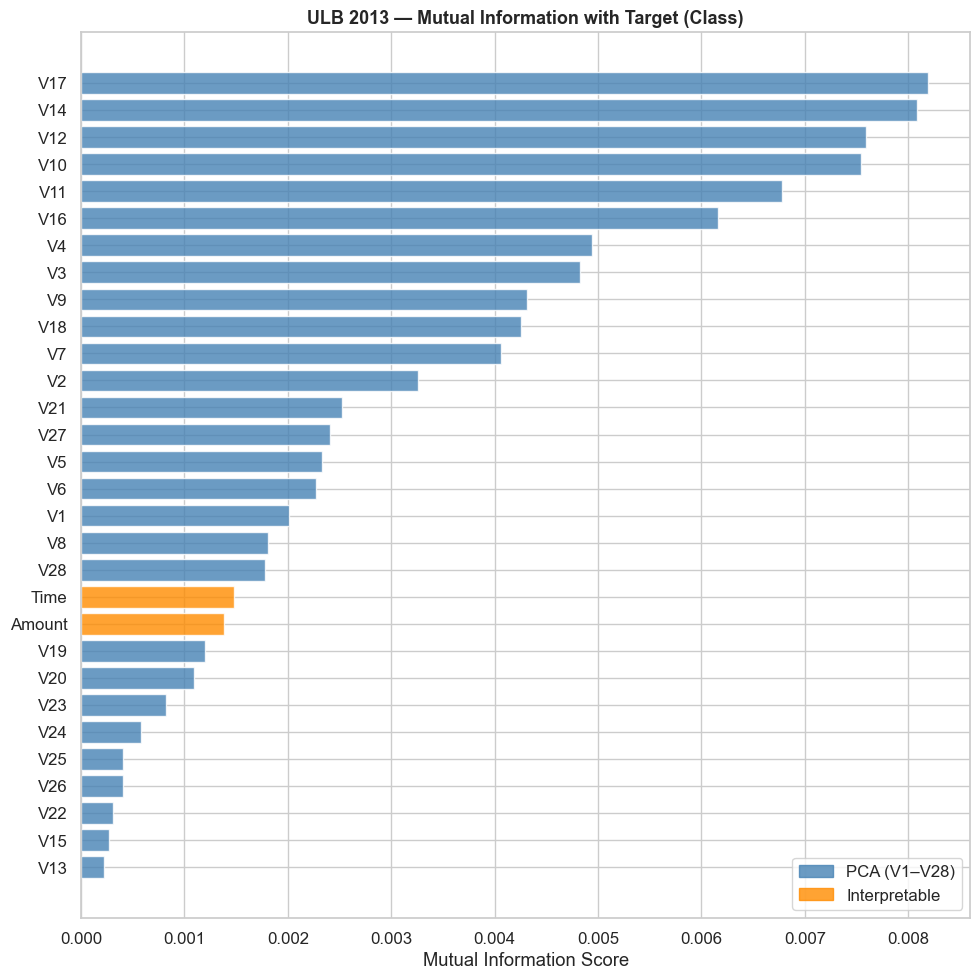


⚠ Features with MI < 0.001 (near-zero relevance):


,Feature,MI Score,Type
23,V23,0.0008,PCA
24,V24,0.0006,PCA
25,V25,0.0004,PCA
26,V26,0.0004,PCA
27,V22,0.0003,PCA
28,V15,0.0003,PCA
29,V13,0.0002,PCA


In [13]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df[ALL_FEATURES]
y_mi = df[TARGET]

# All features are continuous
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42, n_neighbors=5)

mi_df = pd.DataFrame({"Feature": X_mi.columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values("MI Score", ascending=False).reset_index(drop=True)
mi_df["Type"] = mi_df["Feature"].apply(lambda x: "Interpretable" if x in INTERPRETABLE else "PCA")

display(mi_df)

# Bar chart
plt.figure(figsize=(10, 10))
colors = ["darkorange" if t == "Interpretable" else "steelblue" for t in mi_df["Type"]]
plt.barh(mi_df["Feature"], mi_df["MI Score"], color=colors, alpha=0.8)
plt.xlabel("Mutual Information Score")
plt.title("ULB 2013 — Mutual Information with Target (Class)", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()

# Legend
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color="steelblue", alpha=0.8, label="PCA (V1–V28)"),
                     Patch(color="darkorange", alpha=0.8, label="Interpretable")],
           loc="lower right")
plt.tight_layout()
plt.show()

# Low MI features
low_mi = mi_df[mi_df["MI Score"] < 0.001]
if not low_mi.empty:
    print(f"\n⚠ Features with MI < 0.001 (near-zero relevance):")
    display(low_mi)
else:
    print("\n✓ All features have MI ≥ 0.001.")

## 9. Outlier Analysis

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
0,V27,-0.0708,0.0910,0.1619,-0.3137,0.3339,39163,13.7500
1,Amount,5.6000,77.1650,71.5650,-101.7475,184.5125,31904,11.2000
2,V28,-0.0530,0.0783,0.1312,-0.2498,0.2751,30342,10.6500
3,V20,-0.2117,0.1330,0.3448,-0.7289,0.6502,27770,9.7500
4,V8,-0.2086,0.3273,0.5360,-1.0126,1.1313,24134,8.4700
5,V6,-0.7683,0.3986,1.1669,-2.5186,2.1489,22965,8.0600
6,V23,-0.1618,0.1476,0.3095,-0.6261,0.6119,18541,6.5100
7,V12,-0.4056,0.6182,1.0238,-1.9413,2.1540,15348,5.3900
8,V21,-0.2284,0.1864,0.4148,-0.8506,0.8085,14497,5.0900
9,V14,-0.4256,0.4931,0.9187,-1.8037,1.8712,14149,4.9700


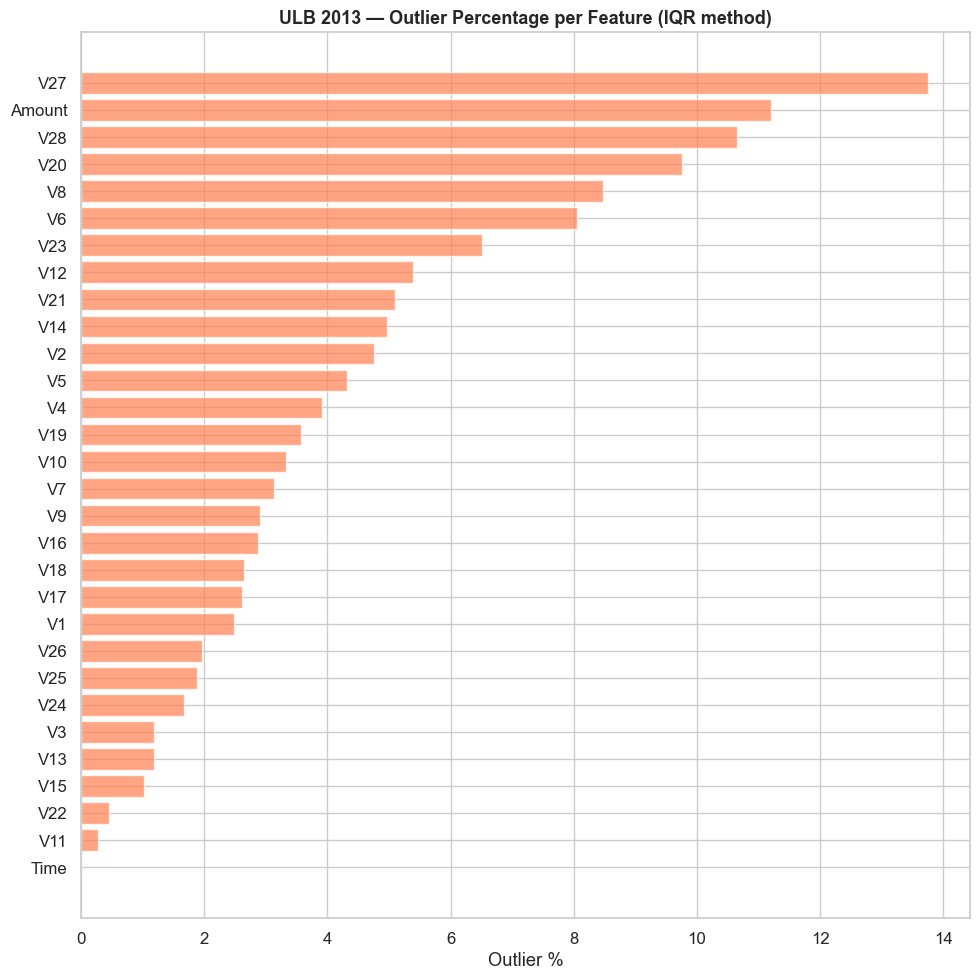

In [14]:
# IQR-based outlier detection for all features
outlier_stats = []
for col in ALL_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_stats.append({
        "Feature": col,
        "Q1": round(Q1, 4),
        "Q3": round(Q3, 4),
        "IQR": round(IQR, 4),
        "Lower Bound": round(lower, 4),
        "Upper Bound": round(upper, 4),
        "Outliers": n_outliers,
        "Outlier %": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values("Outlier %", ascending=False)
display(outlier_df.reset_index(drop=True))

# Bar chart of outlier percentages
plt.figure(figsize=(10, 10))
plt.barh(outlier_df["Feature"], outlier_df["Outlier %"], color="coral", alpha=0.7)
plt.xlabel("Outlier %")
plt.title("ULB 2013 — Outlier Percentage per Feature (IQR method)", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# Are outliers more common in fraud or legit?
print("Outlier proportion by class (top features with most outliers):")
print("=" * 65)
top_outlier_features = outlier_df.head(10)["Feature"].tolist()

class_outlier_data = []
for col in top_outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    is_outlier = (df[col] < lower) | (df[col] > upper)

    for label, name in [(0, "Legit"), (1, "Fraud")]:
        mask = df[TARGET] == label
        n_class = mask.sum()
        n_outlier_class = (is_outlier & mask).sum()
        class_outlier_data.append({
            "Feature": col,
            "Class": name,
            "Outliers in Class": n_outlier_class,
            "Class Size": n_class,
            "Outlier Rate in Class %": round(n_outlier_class / n_class * 100, 2)
        })

co_df = pd.DataFrame(class_outlier_data)
display(co_df.pivot_table(index="Feature", columns="Class",
                          values="Outlier Rate in Class %").round(2))

Outlier proportion by class (top features with most outliers):


Class,Fraud,Legit
Feature,,
Amount,18.5000,11.1900
V12,83.1300,5.2500
V14,87.4000,4.8300
V20,39.4300,9.7000
V21,49.5900,5.0100
V23,30.2800,6.4700
V27,69.9200,13.6500
V28,55.2800,10.5800
V6,27.8500,8.0300


## 10. `Time` and `Amount` Analysis

TIME feature:
  Range: 0 – 172792 seconds
  = 0.0 – 48.0 hours
  Span: ~48 hours (~2 days of transactions)


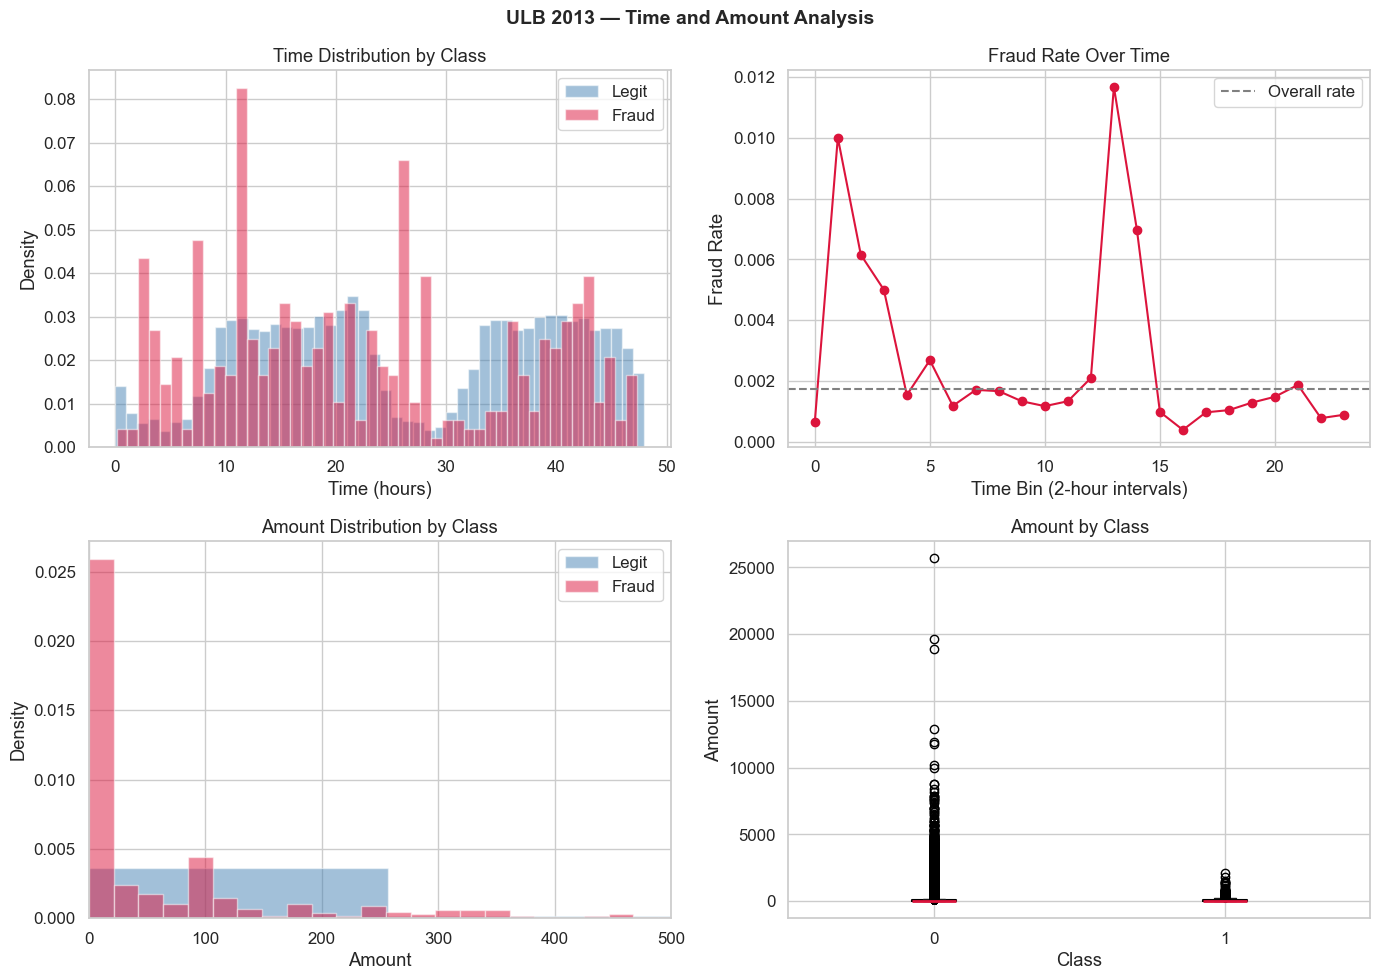


Amount statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0000,88.2900,250.1100,0.0000,5.6500,22.0000,77.0500,25691.1600
1,492.0000,122.2100,256.6800,0.0000,1.0000,9.2500,105.8900,2125.8700


In [16]:
# ── Time Analysis ──
print("TIME feature:")
print(f"  Range: {df['Time'].min():.0f} – {df['Time'].max():.0f} seconds")
print(f"  = {df['Time'].min()/3600:.1f} – {df['Time'].max()/3600:.1f} hours")
print(f"  Span: ~{df['Time'].max()/3600:.0f} hours (~2 days of transactions)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time distribution by class
for label, color, name in [(0, "steelblue", "Legit"), (1, "crimson", "Fraud")]:
    subset = df.loc[df[TARGET] == label, "Time"] / 3600  # convert to hours
    axes[0, 0].hist(subset, bins=48, alpha=0.5, color=color, label=name, density=True)
axes[0, 0].set_xlabel("Time (hours)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Time Distribution by Class")
axes[0, 0].legend()

# Fraud rate over time (binned)
df["time_bin"] = pd.cut(df["Time"] / 3600, bins=24)
fraud_by_time = df.groupby("time_bin", observed=True)[TARGET].agg(["sum", "count", "mean"])
fraud_by_time.columns = ["Frauds", "Total", "Fraud Rate"]
axes[0, 1].plot(range(len(fraud_by_time)), fraud_by_time["Fraud Rate"], "o-", color="crimson")
axes[0, 1].axhline(y=df[TARGET].mean(), color="gray", linestyle="--", label="Overall rate")
axes[0, 1].set_xlabel("Time Bin (2-hour intervals)")
axes[0, 1].set_ylabel("Fraud Rate")
axes[0, 1].set_title("Fraud Rate Over Time")
axes[0, 1].legend()

# Amount distribution by class
for label, color, name in [(0, "steelblue", "Legit"), (1, "crimson", "Fraud")]:
    subset = df.loc[df[TARGET] == label, "Amount"]
    axes[1, 0].hist(subset, bins=100, alpha=0.5, color=color, label=name, density=True)
axes[1, 0].set_xlabel("Amount")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Amount Distribution by Class")
axes[1, 0].set_xlim(0, 500)  # zoom into main range
axes[1, 0].legend()

# Amount boxplot by class
df.boxplot(column="Amount", by=TARGET, ax=axes[1, 1],
           boxprops=dict(linewidth=1.5),
           medianprops=dict(color="crimson", linewidth=2))
axes[1, 1].set_title("Amount by Class")
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("Amount")

df.drop(columns=["time_bin"], inplace=True)

plt.suptitle("ULB 2013 — Time and Amount Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary stats
print("\nAmount statistics by class:")
display(df.groupby(TARGET)["Amount"].describe().round(2))

In [17]:
# Should we keep or drop 'Time'?
print("TIME COLUMN ASSESSMENT")
print("=" * 50)
print()
print("'Time' represents seconds elapsed from the first transaction.")
print("It captures the time-of-day pattern (day/night cycles).")
print()
print("Arguments for KEEPING:")
print("  • May capture time-of-day fraud patterns (e.g., fraud at night)")
print("  • Used by most ULB literature as a standard feature")
print()
print("Arguments for DROPPING:")
print("  • Only 2 days of data — temporal patterns may not generalise")
print("  • Could introduce temporal leakage in random splits")
print("  • The pipeline uses stratified random splits, not temporal")
print()
print("DECISION: Keep 'Time' — it's a standard feature in ULB studies.")
print("The stratified split mitigates most temporal leakage concerns,")
print("and the PCA features already encode the dominant fraud signal.")

TIME COLUMN ASSESSMENT

'Time' represents seconds elapsed from the first transaction.
It captures the time-of-day pattern (day/night cycles).

Arguments for KEEPING:
  • May capture time-of-day fraud patterns (e.g., fraud at night)
  • Used by most ULB literature as a standard feature

Arguments for DROPPING:
  • Only 2 days of data — temporal patterns may not generalise
  • Could introduce temporal leakage in random splits
  • The pipeline uses stratified random splits, not temporal

DECISION: Keep 'Time' — it's a standard feature in ULB studies.
The stratified split mitigates most temporal leakage concerns,
and the PCA features already encode the dominant fraud signal.


## 11. Conclusions & Decisions

In [ ]:
print("" + "=" * 70)
print(" EDA SUMMARY — ULB Credit Card 2013 Dataset")
print("=" * 70)

print(f"\n1. DATASET SIZE: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   ({len(PCA_FEATURES)} PCA features + {len(INTERPRETABLE)} interpretable + 1 target)")

print(f"\n2. MISSING VALUES: {df.isnull().sum().sum()} — dataset is complete.")

fraud_rate = df[TARGET].mean()
print(f"\n3. CLASS IMBALANCE: {fraud_rate:.6f} ({fraud_rate*100:.3f}% fraud)")
print(f"   Ratio: {(1-fraud_rate)/fraud_rate:.0f}:1 (legit:fraud)")
print(f"   Even more extreme than BAF (~1.1% fraud)")

if high_corr_pairs:
    print(f"\n4. HIGH CORRELATION: {len(high_corr_pairs)} feature pair(s) with |r| > 0.70")
    for pair in high_corr_pairs:
        print(f"   • {pair['Feature 1']} ↔ {pair['Feature 2']}: r = {pair['Pearson r']}")
else:
    print(f"\n4. HIGH CORRELATION: None with |r| > 0.70")
    print(f"   PCA features are orthogonal by construction — confirmed.")

print(f"\n5. TOP 5 FEATURES by Mutual Information:")
for _, row in mi_df.head(5).iterrows():
    print(f"   • {row['Feature']:10s}  MI = {row['MI Score']:.4f}  ({row['Type']})")

print(f"\n6. LOWEST MI FEATURES (candidates for removal if MI ≈ 0):")
for _, row in mi_df.tail(5).iterrows():
    print(f"   • {row['Feature']:10s}  MI = {row['MI Score']:.4f}  ({row['Type']})")

print(f"\n7. TIME: Kept — standard feature, captures time-of-day patterns.")
print(f"   AMOUNT: Kept — interpretable, shows fraud/legit differences.")

print("\n" + "=" * 70)
print(" DECISIONS")
print("=" * 70)
print("""
• Keep all 30 features (V1–V28 + Time + Amount) — no columns dropped.
• No imputation needed — zero missing values.
• No feature pairs with |r| > 0.70 — no redundancy to address.
• PCA features are anonymous — no domain-level interpretation possible.
  Interpretability analysis (SHAP) will be limited to feature importance
  rankings without semantic meaning.
• Class imbalance (0.17% fraud) is even more extreme than BAF (1.1%) —
  reinforces the need for imbalance strategies and threshold optimisation.
• StandardScaler should be applied to Time and Amount (already in pipeline)
  since PCA features have varying scales.
""")

 EDA SUMMARY — ULB Credit Card 2013 Dataset

1. DATASET SIZE: 284,807 rows × 31 columns
   (28 PCA features + 2 interpretable + 1 target)

2. MISSING VALUES: 0 — dataset is complete.

3. CLASS IMBALANCE: 0.001727 (0.173% fraud)
   Ratio: 578:1 (legit:fraud)
   Even more extreme than BAF (~1.1% fraud)

4. HIGH CORRELATION: None with |r| > 0.70
   PCA features are orthogonal by construction — confirmed.

5. TOP 5 FEATURES by Mutual Information:
   • V17         MI = 0.0082  (PCA)
   • V14         MI = 0.0081  (PCA)
   • V12         MI = 0.0076  (PCA)
   • V10         MI = 0.0075  (PCA)
   • V11         MI = 0.0068  (PCA)

6. LOWEST MI FEATURES (candidates for removal if MI ≈ 0):
   • V25         MI = 0.0004  (PCA)
   • V26         MI = 0.0004  (PCA)
   • V22         MI = 0.0003  (PCA)
   • V15         MI = 0.0003  (PCA)
   • V13         MI = 0.0002  (PCA)

7. TIME: Kept — standard feature, captures time-of-day patterns.
   AMOUNT: Kept — interpretable, shows fraud/legit differences.

 DE

: 